## Лабораторная 5

1. Построить CNN для бинарной классификации изображений.
2. Загрузить [датасет](https://www.kaggle.com/datasets/sanikamal/horses-or-humans-dataset).
3. Выполнить аугментацию изображений.
4. Обучить модель на обученном датасете.
5. Получить метрику ROC-AUC.
6. Добиться значения ROC-AUC > 0.6.

*Дополнительное задание: 
Сделать интерфейс,, в который можно загружать изображение и получать информацию о том, человек находится на фото или лошадь*

In [1]:
import numpy as np
from tensorflow import keras
from matplotlib import pyplot as plt
import os
import cv2 as cv

In [2]:
# Открываем датасет

def open_imgs_in_folder(folder):
    arr = []
    for filename in os.listdir(folder):
        img = cv.imread(os.path.join(folder,filename))
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img = np.array(img)
        if img is not None:
            arr.append(img)
    return arr

horse_imgs = open_imgs_in_folder("horse-or-human/train/horses")
human_imgs = open_imgs_in_folder("horse-or-human/train/humans")

x_train = [*horse_imgs, *human_imgs]
x_train = np.array(x_train) / 255
y_train = np.vstack(( np.zeros((len(horse_imgs), 1)), 
                     np.ones((len(human_imgs), 1)) ))

horse_imgs_test = open_imgs_in_folder("horse-or-human/validation/horses")
human_imgs_test = open_imgs_in_folder("horse-or-human/validation/humans")

x_test = [*horse_imgs_test, *human_imgs_test]
x_test = np.array(x_test) / 255
y_test = np.vstack(( np.zeros((len(horse_imgs_test), 1)), 
                     np.ones((len(human_imgs_test), 1)) ))

# 0 - для лошади
# 1 - для человека

In [3]:
img_size = (300, 300)
num_of_channels = 3

In [4]:
# This layer can be thought of as an all-in-one image augmentation layer. 
# The policy implemented by this layer has been benchmarked extensively 
# and is effective on a wide variety of datasets. (Из документации)
# Короче, все в одном.
augment_layer = keras.layers.RandAugment(
    value_range=(0, 1),
    num_ops=3,  # Количество разных аугментаций, применяемых к каждой картинке
    factor=0.1, # "Сила" аугментации
    seed=1234
)

In [5]:
model = keras.models.Sequential([
    keras.layers.Input((*img_size, num_of_channels, )),
    augment_layer,
    
    keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(3, 3)), # Shape на выходе - (32, 100, 100)
    keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(4, 4)), # Shape на выходе - (64, 25, 25)
    keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(5, 5)), # Shape на выходе - (128, 5, 5)

    keras.layers.Flatten(), # (3200)
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid")
])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rand_augment (RandAugment)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,748,609 (6.67 MB)

 Trainable params: 1,748,609 (6.67 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                loss=keras.losses.BinaryCrossentropy,
                metrics=[keras.metrics.AUC(curve="ROC", name="auc")])

In [8]:
history = model.fit(x_train, y_train, epochs=20, batch_size=100, validation_data=(x_test, y_test))

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 795ms/step - auc: 0.5294 - loss: 0.6946 - val_auc: 0.8830 - val_loss: 0.6846
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 683ms/step - auc: 0.6510 - loss: 0.6655 - val_auc: 0.9170 - val_loss: 0.6290
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 669ms/step - auc: 0.7612 - loss: 0.6366 - val_auc: 0.9206 - val_loss: 0.6289
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 669ms/step - auc: 0.8165 - loss: 0.5881 - val_auc: 0.9196 - val_loss: 0.5774
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 675ms/step - auc: 0.8459 - loss: 0.5391 - val_auc: 0.9216 - val_loss: 0.7653
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 663ms/step - auc: 0.8716 - loss: 0.4884 - val_auc: 0.9232 - val_loss: 0.6083
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 668ms/step - auc: 0.9043 - loss: 0.4255 - val_auc: 0.9227 - val_loss: 0.5920
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 662ms/step - auc: 0.9350 - loss: 0.3694 - val_auc: 0.9223 - val_loss: 0.5658
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 683ms/step - a

In [9]:
model.evaluate(x_test, y_test, verbose=0)

[0.6015809774398804, 0.958251953125]

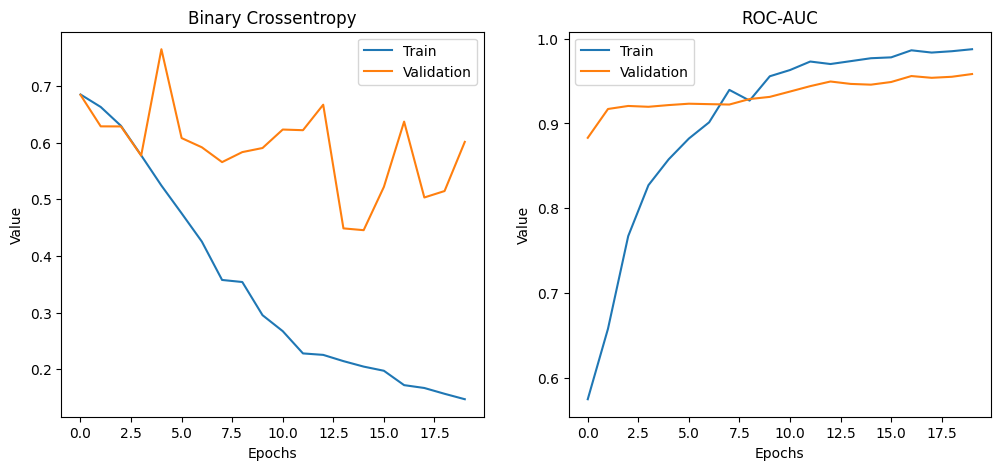

In [10]:
# Строим графики

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history[f"loss"], label="Train")
ax1.plot(history.history[f"val_loss"], label="Validation")
ax1.set_title('Binary Crossentropy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Value')
ax1.legend()

ax2.plot(history.history[f"auc"], label="Train")
ax2.plot(history.history[f"val_auc"], label="Validation")
ax2.set_title('ROC-AUC')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Value')
ax2.legend()

plt.show()